<a href="https://colab.research.google.com/github/JavierCarrillo12/Computacion-visual-jtorresle-jugomezra-dagarzonmo-jacarrillo/blob/main/Talleres/2025-06-06_taller56_kalman_inferencia/kalman_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# 1. Generar datos sintéticos
# -----------------------
np.random.seed(42)
N = 100

# Variable real: por ejemplo un random walk suave
real = np.cumsum(np.random.randn(N) * 0.5)

# Observaciones ruidosas
measurement_noise = np.random.normal(0, 1.0, size=N)
observed = real + measurement_noise

# Simular observaciones incompletas: algunos valores perdidos
mask = np.random.rand(N) < 0.2  # 20% datos faltantes
observed_incomplete = observed.copy()
observed_incomplete[mask] = np.nan

In [2]:
# -----------------------
# 2. Configurar filtro de Kalman 1D
# -----------------------
# Estado: x (la variable que queremos estimar)
# Modelo de proceso: x_k = x_{k-1} + w, w ~ N(0, Q)
# Mediciones: z_k = x_k + v,    v ~ N(0, R)

Q = 0.01   # Varianza del proceso
R = 1.0    # Varianza de la medición

x_hat = 0.0    # Estimación inicial
P = 1.0        # Incertidumbre inicial

estimates = np.zeros(N)

In [3]:
# -----------------------
# 3. Algoritmo de Kalman
# -----------------------
for k in range(N):
    # Predicción
    x_prior = x_hat
    P_prior = P + Q

    z = observed_incomplete[k]
    if np.isnan(z):
        # Sin medición: no hacemos corrección
        x_hat = x_prior
        P = P_prior
    else:
        # Ganancia de Kalman
        K = P_prior / (P_prior + R)
        # Corrección
        x_hat = x_prior + K * (z - x_prior)
        P = (1 - K) * P_prior

    estimates[k] = x_hat

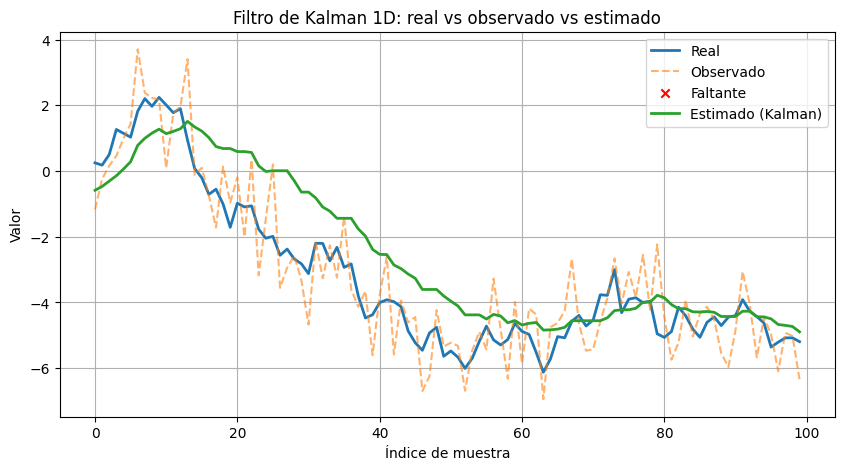

In [4]:
# -----------------------
# 4. Visualización
# -----------------------
plt.figure(figsize=(10,5))
plt.plot(real,    label='Real',        linewidth=2)
plt.plot(observed, label='Observado',  linestyle='--', alpha=0.6)
plt.scatter(np.arange(N)[mask], observed_incomplete[mask],
            color='r', marker='x', label='Faltante', zorder=5)
plt.plot(estimates, label='Estimado (Kalman)', linewidth=2)
plt.legend()
plt.title('Filtro de Kalman 1D: real vs observado vs estimado')
plt.xlabel('Índice de muestra')
plt.ylabel('Valor')
plt.grid(True)
plt.show()